In [ ]:
import os
from pathlib import Path

import contextily as cx
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandana as pdna
import geopandas as gpd
import pandas as pd
import shapely

In [2]:
data_path = Path(os.environ["DATA_PATH"])
generated_path = data_path / "generated"
population_grids_path = Path(os.environ["POPULATION_GRIDS_PATH"])
denue_path = Path(os.environ["DENUE_PATH"])

cache_path = Path("./cache")
cache_path.mkdir(exist_ok=True)

In [3]:
DENUE_TO_AMENITY_MAPPING = [
    # Salud
    {
        "name": "Consultorios médicos",
        "query": 'codigo_act.str.match("^621")',
    },
    {
        "name": "Hospital general",
        "query": 'codigo_act.str.match("^622")',
    },
    {
        "name": "Farmacia",
        "query": 'codigo_act.str.match("^46411")',
    },
    # Recreativo
    {
        "name": "Cine",
        "query": 'codigo_act.str.match("^51213")',
    },
    {
        "name": "Otros servicios recreativos",
        "query": 'codigo_act.str.match("^(71399|712|713)")',
    },
    {
        "name": "Clubs deportivos y de acondicionamiento físico",
        "query": 'codigo_act.str.match("^(71391|71394)")',
    },
    # Educación
    {
        "name": "Guarderia",
        "query": 'codigo_act.str.match("^6244")',
    },
    {
        "name": "Educación preescolar",
        "query": 'codigo_act.str.match("^61111")',
    },
    {"name": "Educación primaria", "query": 'codigo_act.str.match("^61112")'},
    {"name": "Educación secundaria", "query": 'codigo_act.str.match("^(61113|61114)")'},
    {
        "name": "Educación media superior",
        "query": 'codigo_act.str.match("^(61115|61116)")',
    },
    {"name": "Educación superior", "query": 'codigo_act.str.match("^(6112|6113)")'},
]

AMENITIES_DICT = {
    # Salud
    "Hospital general": {
        "pob_query": "POBTOT",
        # Each worker can attend to 20 patients per day
        "attraction_query": "num_workers * 20",
        "radius": 5000,
        "importance": 0.1,
    },
    "Consultorios médicos": {
        "pob_query": "POBTOT",
        # Each worker can attend to 2 patients per hour, 8 hours a day
        "attraction_query": "num_workers * 2 * 8",
        "radius": 2000,
        "importance": 0.05,
    },
    "Farmacia": {
        "pob_query": "POBTOT",
        # Each worker fills 10 prescriptions per hour (daily average), 12 hours a day
        "attraction_query": "num_workers * 10 * 12",
        "radius": 1000,
        "importance": 0.05,
    },
    # Recreativo
    "Parques recreativos": {
        "pob_query": "POBTOT",
        # 30 m² per visitor, 2 turnover cycles per day (morning and afternoon/evening)
        "attraction_query": "area / 30 * 2",
        "radius": 3000,
        "importance": 0.05,
    },
    "Clubs deportivos y de acondicionamiento físico": {
        "pob_query": "P_12A14 + POB15_64",
        "attraction_query": "num_workers * 50",
        "radius": 2000,
        "importance": 0.05,
    },
    "Cine": {
        "pob_query": "POBTOT",
        # 5 workers per screen, 5 movies per day, 25 visitors per movie
        "attraction_query": "num_workers / 5 * 5 * 25",
        "radius": 5000,
        "importance": 0.03,
    },
    "Otros servicios recreativos": {
        "pob_query": "P_12A14 + POB15_64",
        # Each worker can attend to 200 visitors per week, distributed across the week
        "attraction_query": "num_workers * 200 / 7",
        "radius": 3000,
        "importance": 0.02,
    },
    # Educación
    "Guarderia": {
        "pob_query": "P_0A2 + P_3A5",
        # Each worker can attend to 8 children per day
        "attraction_query": "num_workers * 8",
        "radius": 3000,
        "importance": 0.05,
    },
    "Educación preescolar": {
        "pob_query": "P_3A5",
        "attraction_query": "num_workers * 20",
        "radius": 3000,
        "importance": 0.15,
    },
    "Educación primaria": {
        "pob_query": "P_6A11",
        "attraction_query": "num_workers * 30",
        "radius": 3000,
        "importance": 0.15,
    },
    "Educación secundaria": {
        "pob_query": "P_12A14",
        "attraction_query": "num_workers * 30",
        "radius": 3000,
        "importance": 0.15,
    },
    "Educación media superior": {
        "pob_query": "P_15A17",
        "attraction_query": "num_workers * 30",
        "radius": 3000,
        "importance": 0.15,
    },
    "Educación superior": {
        "pob_query": "P_18A24",
        "attraction_query": "num_workers * 40",
        "radius": 3000,
        "importance": 0.15,
    },
}

In [ ]:
df_agebs = gpd.read_file(generated_path / "agebs.gpkg").drop(columns=["accessibility"])

In [6]:
bbox = shapely.box(*df_agebs.total_bounds).buffer(
    1000,
    cap_style="flat",
    join_style="mitre",
)

In [7]:
df_mesh = gpd.read_file(
    population_grids_path / "initial" / "mesh" / "nivel9_1.shp",
).to_crs("EPSG:6372")
df_mesh = df_mesh[df_mesh.intersects(bbox)].copy()

mesh_agg = (
    df_mesh.overlay(
        df_agebs.drop(columns=["zone"]).assign(ageb_area=lambda df: df.area),
    )
    .assign(
        area_fraction=lambda df: df.area / df.ageb_area,
    )
    .drop(columns=["ageb_area", "VIVPAR_HAB", "TVIVPAR", "geometry"], errors="ignore")
)

for c in mesh_agg.columns:
    if not c.startswith("P"):
        continue
    mesh_agg[c] = mesh_agg[c] * mesh_agg["area_fraction"]
mesh_agg = mesh_agg.drop(columns="area_fraction").groupby("CODIGO").sum()

df_mesh = df_mesh.merge(mesh_agg, on="CODIGO", how="left").fillna(0.0)

# Amenities

## DENUE

In [8]:
df_denue: list[gpd.GeoDataFrame] = []

for path in (denue_path / "05-2025").glob("*"):
    if not path.is_dir():
        continue

    shp_list = list((path / "conjunto_de_datos").glob("*.shp"))
    if len(shp_list) == 0:
        err = f"No shapefile found in {path}"
        raise FileNotFoundError(err)

    if len(shp_list) > 1:
        err = f"Multiple shapefiles found in {path}"
        raise FileExistsError(err)

    temp = gpd.read_file(shp_list[0], columns=["per_ocu", "codigo_act", "id"]).to_crs(
        "EPSG:6372",
    )
    temp = temp[temp.intersects(bbox)]
    df_denue.append(temp)

df_denue = (
    pd.concat(df_denue, ignore_index=True)
    .drop_duplicates(subset=["id"])
    .drop(columns=["id"])
    .pipe(gpd.GeoDataFrame, crs="EPSG:6372", geometry="geometry")
    .assign(
        num_workers=lambda x: x["per_ocu"].map(
            {
                "0 a 5 personas": 3,
                "6 a 10 personas": 8,
                "11 a 30 personas": 20,
                "31 a 50 personas": 40,
                "51 a 100 personas": 75,
                "101 a 250 personas": 175,
                "251 y más personas": 500,
            },
        ),
        codigo_act=lambda x: x["codigo_act"].astype(str),
    )[["geometry", "codigo_act", "num_workers"]]
)

for elem in DENUE_TO_AMENITY_MAPPING:
    idx = df_denue.query(elem["query"]).index
    df_denue.loc[idx, "amenity"] = elem["name"]

df_denue = df_denue.dropna(subset=["amenity"]).drop(columns=["codigo_act"])

## Parques

In [9]:
df_park = (
    gpd.read_file(data_path / "initial" / "esp_pub", columns=["TIPO", "Sup_M2"])
    .query(
        "TIPO.isin(['JARDIN VECINAL', 'PARQUE DE BARRIO', 'JARDINES', 'JARDINES (VIVERO MPAL)', 'PARQUE URBANO'])",
    )
    .assign(
        geometry=lambda df: df["geometry"].force_2d().centroid,
        amenity="Parques recreativos",
    )
    .rename(columns={"Sup_M2": "area"})
    .drop(columns=["TIPO"])
    .to_crs("EPSG:6372")
)

## Combinados

In [10]:
df_amenities = pd.concat([df_denue, df_park], ignore_index=True, axis=0).assign(
    attraction=0.0,
)

for amenity_type in df_amenities["amenity"].unique():
    df_amenities.loc[df_amenities["amenity"] == amenity_type, "attraction"] = (
        df_amenities.loc[df_amenities["amenity"] == amenity_type].eval(
            AMENITIES_DICT[amenity_type]["attraction_query"],
        )
    )

# Red

In [11]:
def load_roads(
    bounds: tuple, g_path: Path, *, force_download: bool = False
) -> tuple[gpd.GeoDataFrame]:
    if g_path.exists() and not force_download:
        print("Loading prev road file.")
        g = ox.load_graphml(g_path)
    else:
        g = ox.graph_from_bbox(bbox=bounds, network_type="drive")
        ox.save_graphml(g, g_path)

    nodes, edges = ox.graph_to_gdfs(g)
    nodes = nodes.to_crs("EPSG:6372").filter(["geometry"])
    edges = edges.to_crs("EPSG:6372").reset_index()[["u", "v", "length"]]

    return nodes, edges

In [12]:
NUM_POIS = 5

bounds_agebs = tuple(
    df_agebs.to_crs("EPSG:4326").total_bounds,
)
bounds_mesh = tuple(
    df_mesh.to_crs("EPSG:4326").total_bounds,
)
total_bounds = (
    min(bounds_agebs[0], bounds_mesh[0]),
    min(bounds_agebs[1], bounds_mesh[1]),
    max(bounds_agebs[2], bounds_mesh[2]),
    max(bounds_agebs[3], bounds_mesh[3]),
)

nodes, edges = load_roads(total_bounds, cache_path / "road_network.graphml")

net_accessibility = pdna.Network(
    nodes["geometry"].x.copy(),
    nodes["geometry"].y.copy(),
    edges["u"].copy(),
    edges["v"].copy(),
    edges[["length"]].copy(),
)

# Assign POIS to network
for amenity_type in df_amenities["amenity"].unique():
    to_gdf = df_amenities[df_amenities["amenity"] == amenity_type]
    net_accessibility.set_pois(
        category=amenity_type,
        x_col=to_gdf.geometry.centroid.x,
        y_col=to_gdf.geometry.centroid.y,
        maxdist=200000,
        maxitems=NUM_POIS,
        mapping_distance=1000,
    )

In [13]:
mesh_osmid = (
    df_mesh[["CODIGO", "geometry"]]
    .sjoin(nodes, how="inner", predicate="contains")
    .merge(nodes, on="osmid")
    .assign(cent_dist=lambda df: df.geometry_x.centroid.distance(df.geometry_y))
    .loc[lambda df: df.groupby("CODIGO").cent_dist.idxmin()][["CODIGO", "osmid"]]
)

df_mesh = df_mesh.merge(mesh_osmid, how="left", on="CODIGO")

In [14]:
df_amenities["osmid"] = net_accessibility.get_node_ids(
    x_col=df_amenities["geometry"].centroid.x,
    y_col=df_amenities["geometry"].centroid.y,
    mapping_distance=1000,
)

In [15]:
mesh_osmid = df_mesh[df_mesh["osmid"].notna()]
for c in df_mesh.columns:
    if not c.startswith("P"):
        continue
    net_accessibility.set(mesh_osmid["osmid"], variable=mesh_osmid[c], name=c)

In [17]:
for c in df_mesh.columns:
    if not c.startswith("P"):
        continue
    df_amenities = df_amenities.merge(
        net_accessibility.aggregate(1000, "sum", "exp", name=c).rename(c),
        on="osmid",
        how="left",
    )

In [19]:
df_amenities["reached_population"] = 0.0
for amenity_type in df_amenities.amenity.unique():
    query = AMENITIES_DICT[amenity_type]["pob_query"]
    df_amenities.loc[df_amenities["amenity"] == amenity_type, "reached_population"] = (
        df_amenities.loc[df_amenities["amenity"] == amenity_type].eval(query)
    )

df_amenities["adj_attraction"] = (
    df_amenities.attraction
    / df_amenities.reached_population.where(df_amenities.reached_population > 1, 1)
)

In [23]:
destinations = df_amenities.groupby("osmid").adj_attraction.sum()
destinations.head()

osmid
62787573       0.551678
87697443      48.000000
87712967     456.000000
181285372      0.677514
181285416      0.164946
Name: adj_attraction, dtype: float64

In [24]:
net_accessibility.set(destinations.index, variable=destinations.values, name="attr")

In [25]:
df_mesh = df_mesh.merge(
    net_accessibility.aggregate(1000, "sum", "exp", name="attr").rename(
        "accessibility"
    ),
    on="osmid",
    how="left",
)

In [27]:
df_mesh = df_mesh.assign(
    accessibility_score=lambda df: (
        (np.log(df["accessibility"].fillna(0.0) + 1) * 12.5).clip(0, 100) / 100
    ),
)

In [ ]:
df_access = (
    gpd.GeoDataFrame(
        df_agebs.set_index("CVEGEO")[["geometry"]]
        .sjoin(df_mesh[["geometry", "accessibility_score"]], how="left")
        .groupby("CVEGEO")
        .agg({"accessibility_score": "mean", "geometry": "first"}),
        crs=df_mesh.crs,
    )
    .reset_index()
    .rename(columns={"accessibility_score": "accessibility"})
)
df_access.head()

,CVEGEO,accessibility,geometry
0,0200200010019,0.094780,"POLYGON ((1240836.538 2335789.786, 1240836.059..."
1,0200200010023,0.035692,"POLYGON ((1240864.547 2335052.842, 1240781.408..."
2,0200200010038,0.128310,"POLYGON ((1239641.963 2334838.629, 1239639.679..."
3,0200200010042,0.381921,"POLYGON ((1225449.578 2348799.553, 1225449.093..."
4,0200200010057,0.381885,"POLYGON ((1225449.578 2348799.553, 1225744.357..."


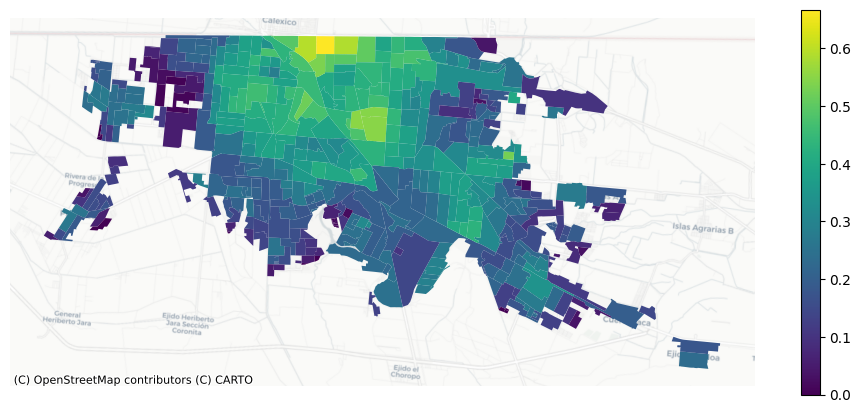

In [47]:
fig, ax = plt.subplots(figsize=(12, 5))
df_access.plot(column="accessibility", cmap="viridis", legend=True, ax=ax)
ax.axis("off")
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=12, crs=df_access.crs)

In [50]:
df_agebs.set_index("CVEGEO").assign(
    accessibility=df_access.set_index("CVEGEO")["accessibility"]
).to_file(generated_path / "agebs.gpkg")

In [48]:
df_agebs

,CVEGEO,zone,POBTOT,P_60YMAS,P_0A2,P_3A5,P_6A11,P_12A14,P_15A17,P_18A24,POB15_64,TVIVPAR,TVIVPARHAB,GRAPROES,income,vacant_area_frac,crimes,area_km2,geometry
0,0200200010019,5,2943,91.0,139.0,176.0,431.0,169.0,143.0,325.0,1974.0,1032,889,9.08,4.769395,0.128376,278.0,0.297102,"POLYGON ((1240836.538 2335789.786, 1240836.059..."
1,0200200010023,5,2377,71.0,120.0,138.0,314.0,142.0,115.0,270.0,1627.0,960,765,9.31,4.931883,0.070573,287.0,0.264551,"POLYGON ((1240864.547 2335052.842, 1240781.408..."
2,0200200010038,5,6104,100.0,419.0,473.0,750.0,288.0,256.0,911.0,4125.0,2458,1969,9.23,4.373754,0.068269,245.0,0.564767,"POLYGON ((1239641.963 2334838.629, 1239639.679..."
3,0200200010042,3,1293,294.0,20.0,42.0,81.0,35.0,53.0,124.0,903.0,520,447,9.42,5.048268,0.049958,234.0,0.453839,"POLYGON ((1225449.578 2348799.553, 1225449.093..."
4,0200200010057,3,1465,297.0,26.0,30.0,99.0,45.0,50.0,142.0,1072.0,698,605,8.77,4.788611,0.065495,529.0,0.445666,"POLYGON ((1225449.578 2348799.553, 1225744.357..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,0200200018457,0,406,3.0,19.0,42.0,55.0,19.0,18.0,36.0,271.0,120,119,11.66,6.173791,0.018737,10.0,0.037963,"POLYGON ((1239802.588 2339963.796, 1239786.139..."
427,0200200018476,5,1199,17.0,87.0,89.0,162.0,64.0,45.0,147.0,790.0,418,369,9.02,NaN,0.121364,97.0,0.109249,"POLYGON ((1239055.891 2335693.568, 1239130.859..."
428,0200200018495,0,3524,62.0,242.0,300.0,440.0,158.0,98.0,355.0,2342.0,1241,1167,10.65,5.536188,0.231823,4.0,0.492035,"POLYGON ((1241020.335 2339087.609, 1241006.271..."
429,0200202277868,5,1578,179.0,73.0,72.0,162.0,73.0,84.0,209.0,1082.0,580,473,9.07,4.620709,NaN,17.0,0.950744,"POLYGON ((1246394.982 2333777.555, 1246590.545..."
